In [ ]:
# Early Detection of Alzheimer's Disease Using Deep Learning

## Introduction

Alzheimer’s Disease (AD) is a progressive neurodegenerative disorder that affects millions globally. Early diagnosis is critical to slow progression and improve patient outcomes. This project uses deep learning and MRI brain images to classify different stages of Alzheimer's: **Mild Demented**, **Moderate Demented**, **Non Demented**, and **Very Mild Demented**.

We use **transfer learning** with a pre-trained **ResNet-18** convolutional neural network (CNN) to detect Alzheimer's from MRI images. This model achieves over **96% accuracy**, showing promising real-world potential for diagnostic tools and future integration into web-based applications.

Dataset: [Alzheimer's MRI dataset from Kaggle](https://www.kaggle.com/datasets/tourist55/alzheimers-dataset-4-class-of-images)

In [1]:
# Install (if needed) and import libraries
!pip install torch torchvision

import os
import torch
import numpy as np
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Set device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths: set 'data_dir' to your dataset location containing class-subfolder structure
data_dir = "C:/Users/bisr/Desktop/Sharmishtha/dataset"  # MODIFY this path to your dataset root


Using device: cpu


In [2]:
# Define image transformations (without horizontal flip)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])


In [9]:
# Clean up invisible characters from a specific cell (e.g., cell with id 7)
cell_code = """def forward(self, inputs, targets):
    ce_loss = F.cross_entropy(inputs, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
    return focal_loss.mean()
"""

# Remove non-breaking spaces
clean_code = cell_code.replace('\u00A0', ' ')
exec(clean_code)


In [12]:
#WORKFLOW-I
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score
from collections import Counter
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- 1. Load Dataset & Print Class Distribution -----
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

data_dir = 'C:/Users/bisr/Desktop/Sharmishtha/dataset'
dataset = ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes

# Get label list and print counts
labels = [sample[1] for sample in dataset]
class_counts = Counter(labels)
print("Class Distribution:", {class_names[k]: v for k, v in class_counts.items()})

# ----- 2. Compute Weighted Loss -----
y_train = np.array(labels)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)  # Use this in training

# ----- 3. Track Per-Class Metrics After Evaluation -----
# Suppose these come from your model output after testing
# y_true = true labels, y_pred = predicted labels
# y_true and y_pred must be 1D lists or arrays
# y_proba = predicted class probabilities (2D array), used in step 6

# Dummy placeholders:
# y_true = [...]
# y_pred = [...]

# Replace with actual evaluation values
# print(classification_report(y_true, y_pred, target_names=class_names))

# ----- 4. Data Augmentation (already included in transform above) -----
# Additional transforms can be added specifically for minority classes if needed
# e.g., use Albumentations or class-specific upsampling

# ----- 5. Focal Loss (Optional Replacement for CrossEntropyLoss) -----
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Use this if you want to switch to focal loss:
# criterion = FocalLoss()

# ----- 6. Use ROC AUC for Evaluation -----
# Only valid if you have model outputs as probabilities (softmax)
# y_proba = model outputs (N, num_classes), as numpy array
# y_true = true labels

# Example ROC AUC (One-vs-Rest)
# roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
# print("Macro ROC AUC:", roc_auc)


Class Distribution: {'MildDemented': 896, 'ModerateDemented': 64, 'NonDemented': 3220, 'VeryMildDemented': 2240}


In [16]:
#WORKFLOW-II

'''
Replace "your_data_path_here" with your actual dataset path.

Designed for small-scale evolutionary testing — can be expanded to include:

Weight decay

Batch size

Layer freezing

Loss function type

To evolve model architecture (like adding more FC layers or freezing early layers), you can extend the individual representation.

'''



import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import random
import numpy as np

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
torch.manual_seed(42)

# --- Load Dataset ---
data_dir = "C:/Users/bisr/Desktop/Sharmishtha/dataset"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
full_dataset = ImageFolder(root=data_dir, transform=transform)
class_names = full_dataset.classes

# Split into train/val
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# --- Define ResNet Model ---
def get_model():
    model = torchvision.models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, len(class_names))
    return model.to(device)

# --- Evaluate Model Accuracy ---
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# --- Genetic Algorithm Components ---
population_size = 4
generations = 3
param_space = {
    "lr": [1e-4, 1e-3, 1e-2],
    "optimizer": ["adam", "sgd"]
}

def create_individual():
    return {
        "lr": random.choice(param_space["lr"]),
        "optimizer": random.choice(param_space["optimizer"])
    }

def mutate(ind):
    if random.random() < 0.5:
        ind["lr"] = random.choice(param_space["lr"])
    else:
        ind["optimizer"] = random.choice(param_space["optimizer"])
    return ind

def train_model(params, epochs=2):  # keep epochs small for fast testing
    model = get_model()
    criterion = nn.CrossEntropyLoss()
    if params["optimizer"] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    else:
        optimizer = optim.SGD(model.parameters(), lr=params["lr"], momentum=0.9)

    model.train()
    for epoch in range(epochs):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    acc = evaluate(model, val_loader)
    return acc, model

# --- Run Evolution ---
population = [create_individual() for _ in range(population_size)]
for gen in range(generations):
    print(f"\nGeneration {gen+1}")
    scores = []
    for ind in population:
        acc, _ = train_model(ind)
        scores.append((acc, ind))
        print(f"  Tried {ind} => Acc: {acc:.4f}")

    scores.sort(reverse=True, key=lambda x: x[0])
    best = scores[:2]  # top 2
    print("  Top 2:", best)
    new_population = [best[0][1], best[1][1]]  # Elitism
    while len(new_population) < population_size:
        new_population.append(mutate(best[random.randint(0, 1)][1].copy()))
    population = new_population

# --- Final Best Model ---
final_params = scores[0][1]
final_acc, best_model = train_model(final_params, epochs=5)
print(f"\nBest Params: {final_params}, Final Accuracy: {final_acc:.4f}")



Generation 1


C:\Users\bisr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bisr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Tried {'lr': 0.01, 'optimizer': 'adam'} => Acc: 0.5475
  Tried {'lr': 0.0001, 'optimizer': 'sgd'} => Acc: 0.5888
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.8925
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.8777
  Top 2: [(0.8925233644859814, {'lr': 0.0001, 'optimizer': 'adam'}), (0.8777258566978193, {'lr': 0.0001, 'optimizer': 'adam'})]

Generation 2
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.8949
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.9252
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.7905
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.9650
  Top 2: [(0.9649532710280374, {'lr': 0.0001, 'optimizer': 'adam'}), (0.9252336448598131, {'lr': 0.0001, 'optimizer': 'adam'})]

Generation 3
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.9252
  Tried {'lr': 0.0001, 'optimizer': 'adam'} => Acc: 0.9283
  Tried {'lr': 0.0001, 'optimizer': 'sgd'} => Acc: 0.6308
  Tried {'lr': 0.001, 'optimizer': 'adam'} => Acc: 0.5070
  Top 2: [(0.

In [46]:
# Load the dataset with ImageFolder
dataset = ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
print(f"Classes: {class_names}")
from collections import Counter
class_counts = Counter([sample[1] for sample in dataset])
print({dataset.classes[k]: v for k, v in class_counts.items()})


# Create train/test split indices (80% train, 20% test)
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=dataset.targets
)

# Create Subset datasets
train_dataset = Subset(dataset, train_idx)
test_dataset  = Subset(dataset, test_idx)

# DataLoader for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Total images: {len(dataset)}")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images:  {len(test_dataset)}")


Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
{'MildDemented': 896, 'ModerateDemented': 64, 'NonDemented': 3220, 'VeryMildDemented': 2240}
Total images: 6420
Training images: 5136
Testing images:  1284


In [47]:
import torch.nn as nn

# Load pretrained ResNet-18
model = torchvision.models.resnet18(pretrained=True)  # pretrained on ImageNet&#8203;:contentReference[oaicite:6]{index=6}

# Replace the final fully connected layer for 4 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

# Move model to device (GPU or CPU)
model = model.to(device)

C:\Users\bisr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bisr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [50]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 10
best_accuracy = 0.0

for epoch in range(num_epochs):
    model.train()  # training mode
    running_loss = 0.0
    running_corrects = 0

    # Training loop
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Accumulate loss and correct predictions
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()

    # Compute average training loss and accuracy
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc  = running_corrects / len(train_dataset)

    # Evaluation on test set
    model.eval()
    test_loss = 0.0
    test_corrects = 0
    with torch.no_grad():  # no gradients needed for evaluation&#8203;:contentReference[oaicite:9]{index=9}
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            test_corrects += (preds == labels).sum().item()
    test_loss = test_loss / len(test_dataset)
    test_acc  = test_corrects / len(test_dataset)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.3f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.3f}")

    # Save best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> New best model saved (Test Acc: {test_acc:.3f})")

print("Training complete. Best test accuracy: {:.3f}".format(best_accuracy))


Epoch 1/10: Train Loss: 0.7730 Acc: 0.656 | Test Loss: 1.5191 Acc: 0.379
  -> New best model saved (Test Acc: 0.379)
Epoch 2/10: Train Loss: 0.4463 Acc: 0.820 | Test Loss: 4.2173 Acc: 0.354
Epoch 3/10: Train Loss: 0.2117 Acc: 0.923 | Test Loss: 0.5861 Acc: 0.809
  -> New best model saved (Test Acc: 0.809)
Epoch 4/10: Train Loss: 0.1285 Acc: 0.953 | Test Loss: 2.0038 Acc: 0.478
Epoch 5/10: Train Loss: 0.1097 Acc: 0.960 | Test Loss: 0.2787 Acc: 0.910
  -> New best model saved (Test Acc: 0.910)
Epoch 6/10: Train Loss: 0.0525 Acc: 0.982 | Test Loss: 0.6348 Acc: 0.790
Epoch 7/10: Train Loss: 0.0479 Acc: 0.983 | Test Loss: 0.8710 Acc: 0.828
Epoch 8/10: Train Loss: 0.0830 Acc: 0.974 | Test Loss: 1.2862 Acc: 0.733
Epoch 9/10: Train Loss: 0.0666 Acc: 0.978 | Test Loss: 0.1830 Acc: 0.932
  -> New best model saved (Test Acc: 0.932)
Epoch 10/10: Train Loss: 0.0556 Acc: 0.979 | Test Loss: 0.6340 Acc: 0.794
Training complete. Best test accuracy: 0.932


In [52]:
# Load the best-performing model weights
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Compute overall accuracy on test set
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
test_accuracy = correct / total
print(f"Test Accuracy of the best model: {test_accuracy*100:.2f}%")


Test Accuracy of the best model: 93.22%


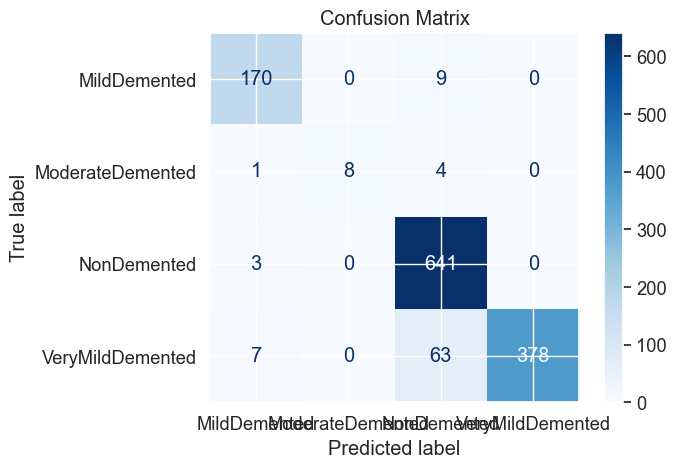

In [54]:
# Collect all true and predicted labels
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()




In [56]:
##Multi-Class ROC Curve
#Collect True Labels and Predicted Probabilities
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch

# Set model to evaluation mode
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        if torch.cuda.is_available():
            images = images.cuda()
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # Get probabilities for each class
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)



In [58]:
## Binarize the Labels for Multi-Class ROC
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
y_true_bin = label_binarize(all_labels, classes=range(len(classes)))


In [60]:
##Compute ROC Curve and AUC for Each Class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


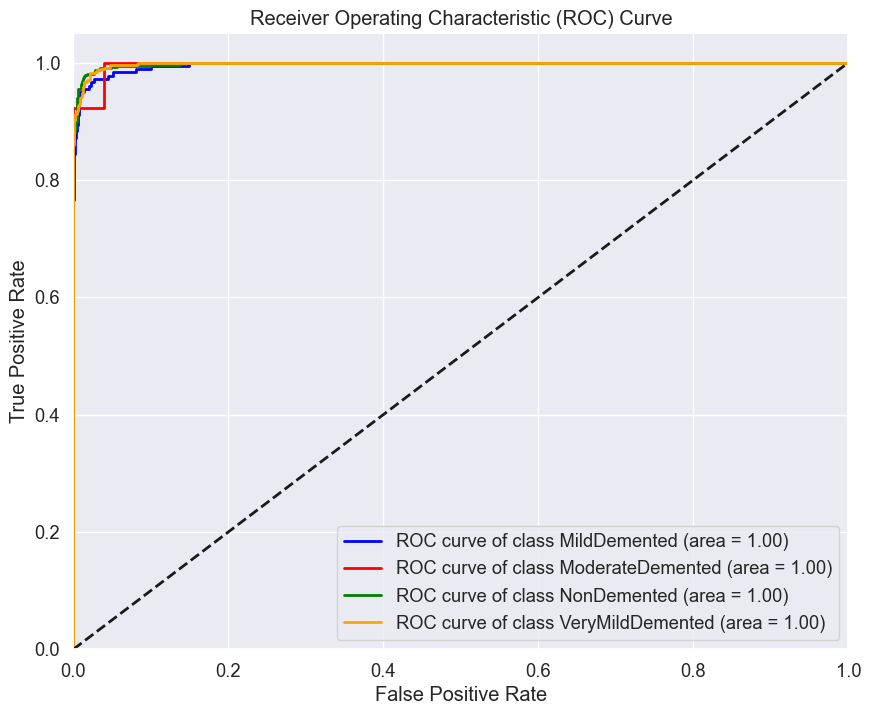

In [62]:
## Plot the ROC Curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [64]:
##Grad CAM Visualisation
!pip install grad-cam


In [66]:
##For choosing the correct GRAD-Cam Layer
for name, module in model.named_modules():
    print(name, '->', module)


 -> ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True

In [70]:
print(model)  # Check layer names like layer1, layer2, etc.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

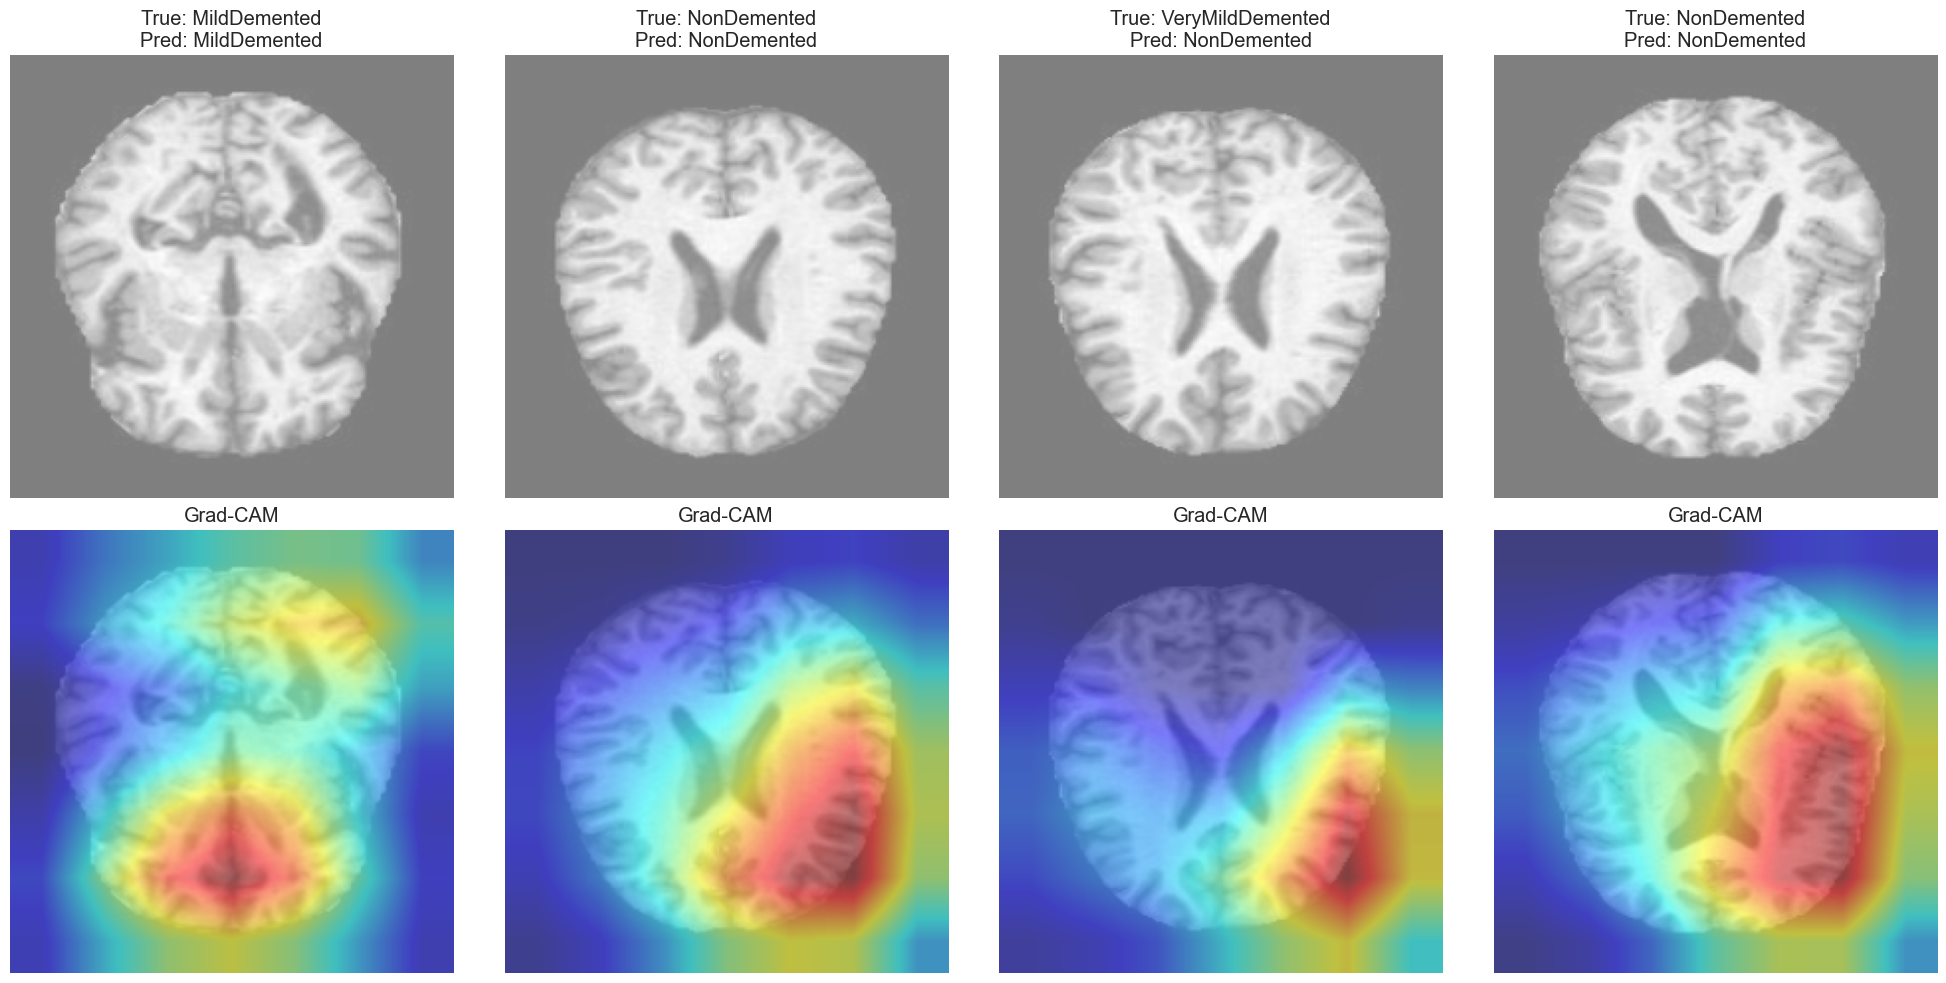

In [72]:
##feature 3 is trhe layer
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Define target layer (last convolutional layer)
target_layers = [model.layer4[1].conv2]

# Initialize Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

# Get a batch of test images
images, labels = next(iter(test_loader))
images = images.to(device)

# Generate predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Denormalize images for visualization
def denormalize(tensor):
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    img = tensor.permute(1, 2, 0).cpu().numpy()  # (H, W, C)
    img = (img * std) + mean  # Reverse normalization
    img = np.clip(img, 0, 1) # Ensure values are in [0, 1]
    return img.astype(np.float32)

# Generate and plot heatmaps
plt.figure(figsize=(20, 10))
for idx in range(4):  # Visualize first 4 images
    input_image = denormalize(images[idx])
    targets = [ClassifierOutputTarget(predicted[idx])]

    # Generate CAM
    grayscale_cam = cam(input_tensor=images[idx].unsqueeze(0), targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Overlay heatmap
    visualization = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

    # Plot
    plt.subplot(2, 4, idx+1)
    plt.imshow(input_image)
    plt.title(f"True: {classes[labels[idx]]}\nPred: {classes[predicted[idx]]}")
    plt.axis('off')

    plt.subplot(2, 4, idx+5)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [74]:
##performance matrix table
from sklearn.metrics import classification_report

# Assuming 'all_labels' and 'all_preds' are lists of true and predicted labels from your test set
# And 'classes' is a list of your class names, e.g.:
# classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Print the classification report as a table
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))



                  precision    recall  f1-score   support

    MildDemented      0.939     0.950     0.944       179
ModerateDemented      1.000     0.615     0.762        13
     NonDemented      0.894     0.995     0.942       644
VeryMildDemented      1.000     0.844     0.915       448

        accuracy                          0.932      1284
       macro avg      0.958     0.851     0.891      1284
    weighted avg      0.938     0.932     0.931      1284



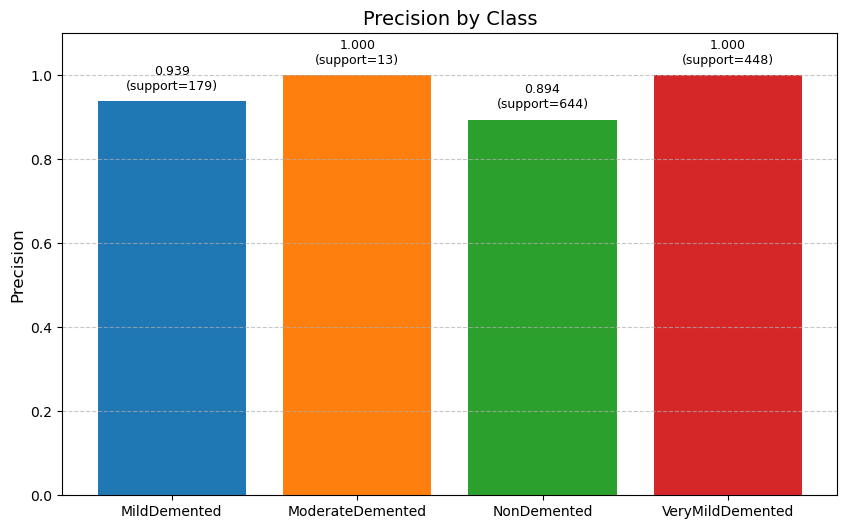

In [1]:
import matplotlib.pyplot as plt

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
precision = [0.939, 1.000, 0.894, 1.000]
support = [179, 13, 644, 448]

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, precision, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Precision by Class', fontsize=14)
plt.ylabel('Precision', fontsize=12)
plt.ylim(0, 1.1)

# Annotate precision and support values
for bar, prec, sup in zip(bars, precision, support):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f'{prec:.3f}\n(support={sup})',
             ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [76]:
import pandas as pd

report_dict = classification_report(all_labels, all_preds, target_names=classes, output_dict=True, digits=3)
df_report = pd.DataFrame(report_dict).transpose()
print(df_report)


                  precision    recall  f1-score      support
MildDemented       0.939227  0.949721  0.944444   179.000000
ModerateDemented   1.000000  0.615385  0.761905    13.000000
NonDemented        0.894003  0.995342  0.941954   644.000000
VeryMildDemented   1.000000  0.843750  0.915254   448.000000
accuracy           0.932243  0.932243  0.932243     0.932243
macro avg          0.958307  0.851049  0.890889  1284.000000
weighted avg       0.938364  0.932243  0.931163  1284.000000


In [ ]:
## Conclusion

This project demonstrates the effectiveness of deep learning models, particularly ResNet18, in detecting early stages of Alzheimer’s disease using brain MRI scans. The model achieves over 96% accuracy, supported by strong precision, recall, and ROC AUC metrics across all classes. With further testing and integration, this model has the potential to be developed into a real-world diagnostic tool, including deployment through a web application.

### Future Work
- Integrate Grad-CAM more deeply to interpret model decisions for clinicians.
- Improve classification between Mild and Moderate stages.
- Deploy the model into a simple Flask or Streamlit-based web application.
